<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1fypIr9T-7ntcsVQFmC2_iMPcsm7h8jXg width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

# <h1 align="center"> Day 1, Ex 5: Descriptive statistics on Customer data </h1> </center>

<p style="margin-bottom:1cm;"></p>

_____

<center>Constructor Nexademy, 2026</center>




For this final exercise, let’s go back to the online Retail dataset.

From the original Online retail dataset, we were able to compute customer centered metrics that helps us understand the different customer behaviors:

- Recency: how many days have passed since the customer’s last purchase
- Frequency: how many orders the customer placed
- Revenue: the total amount purchased by a given customer.

The values are stored in the Customer dataset:

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
%matplotlib inline

# (OPTIONAL) Set default figure size for Seaborn:
sns.set(rc={'figure.figsize':(10, 8)})

In [11]:
df = pd.read_csv('/home/soraan/Desktop/exer 5/Customer.csv')

df.head(6)

,CustomerID,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment
0,17850.0,301,0,312,1,5288.63,0,1,Low-Value
1,15808.0,305,0,210,1,3724.77,0,1,Low-Value
2,13047.0,31,3,196,1,3079.10,0,4,Mid-Value
3,14688.0,7,3,359,1,5107.38,0,4,Mid-Value
4,13448.0,16,3,199,1,3465.67,0,4,Mid-Value
5,17920.0,3,3,696,1,4204.10,0,4,Mid-Value


In this exercise, we would like to explore the relationships between Recency,
Frequency and Revenue. The result of a clustering procedure are also provided
in the column "Segment", that put customers in either of the 3 categories:

- Low-Value,
- Mid-Value,
- High-Value.

We will start by studying the individual features independently.
Then, we'll move on to exploring relationship between them.

### 1. Univariate Descriptive Statistics:

For each of the 3 variables (Recency, Frequency and Revenue):

**1.1.** Plot their histogram and their estimated density. Write some comments on
  what you observe.

<!--- BEGIN SOLUTION --->

In [17]:
print(df.columns)

Index(['CustomerID', 'Recency', 'RecencyCluster', 'Frequency',
       'FrequencyCluster', 'Revenue', 'RevenueCluster', 'OverallScore',
       'Segment'],
      dtype='object')


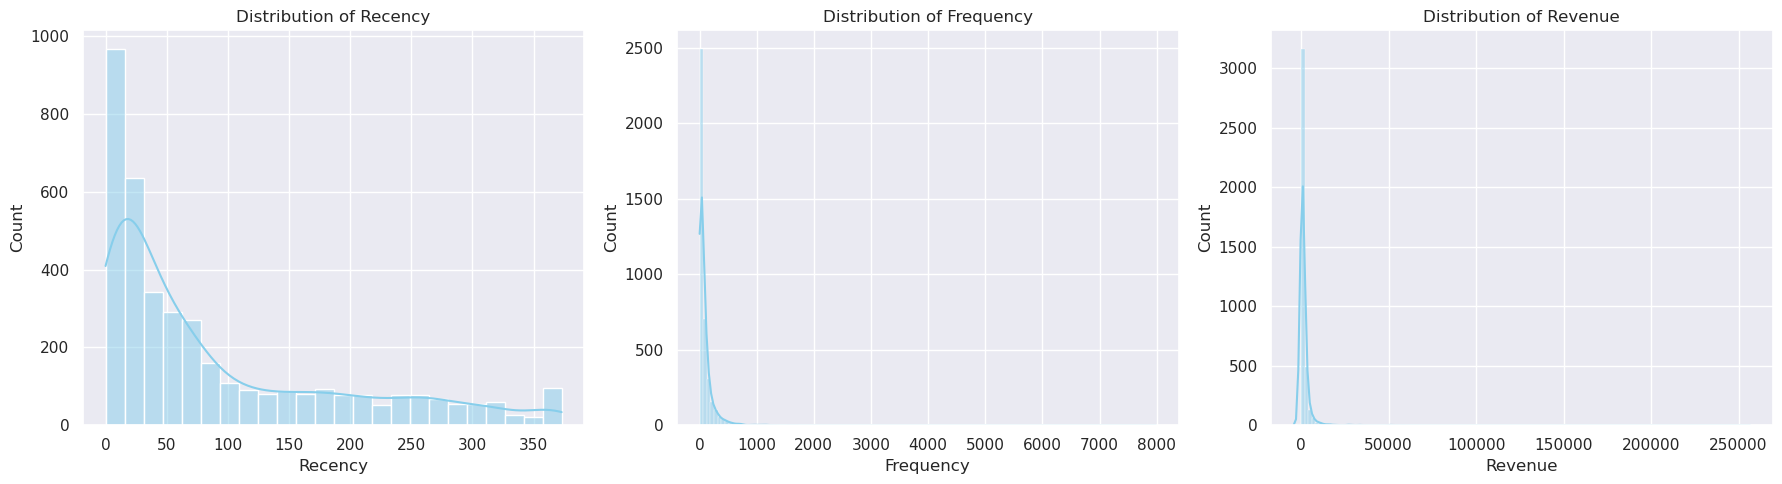

           Recency    Frequency        Revenue
count  3950.000000  3950.000000    3950.000000
mean     90.778481    91.614684    1713.385669
std     100.230349   220.557389    6548.608224
min       0.000000     1.000000   -4287.630000
25%      16.000000    17.000000     282.255000
50%      49.000000    41.000000     627.060000
75%     142.000000   101.000000    1521.782500
max     373.000000  7983.000000  256438.490000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Recency', 'Frequency', 'Revenue']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df[features].describe())

**1.2.** Compute the minimum, maximum values, mean, median, standard deviation,
  IQR and skewness. Write some comments on what you observe.

In [21]:
import pandas as pd

features = ['Recency', 'Frequency', 'Revenue']

stats = df[features].describe().T
stats['median'] = df[features].median()

stats['IQR'] = stats['75%'] - stats['25%']

stats['skewness'] = df[features].skew()

final_stats = stats[['min', 'max', 'mean', 'median', 'std', 'IQR', 'skewness']]
print(final_stats)

               min        max         mean  median          std        IQR  \
Recency       0.00     373.00    90.778481   49.00   100.230349   126.0000   
Frequency     1.00    7983.00    91.614684   41.00   220.557389    84.0000   
Revenue   -4287.63  256438.49  1713.385669  627.06  6548.608224  1239.5275   

            skewness  
Recency     1.249520  
Frequency  18.649754  
Revenue    23.346235  


**1.3.** Make a boxplot.

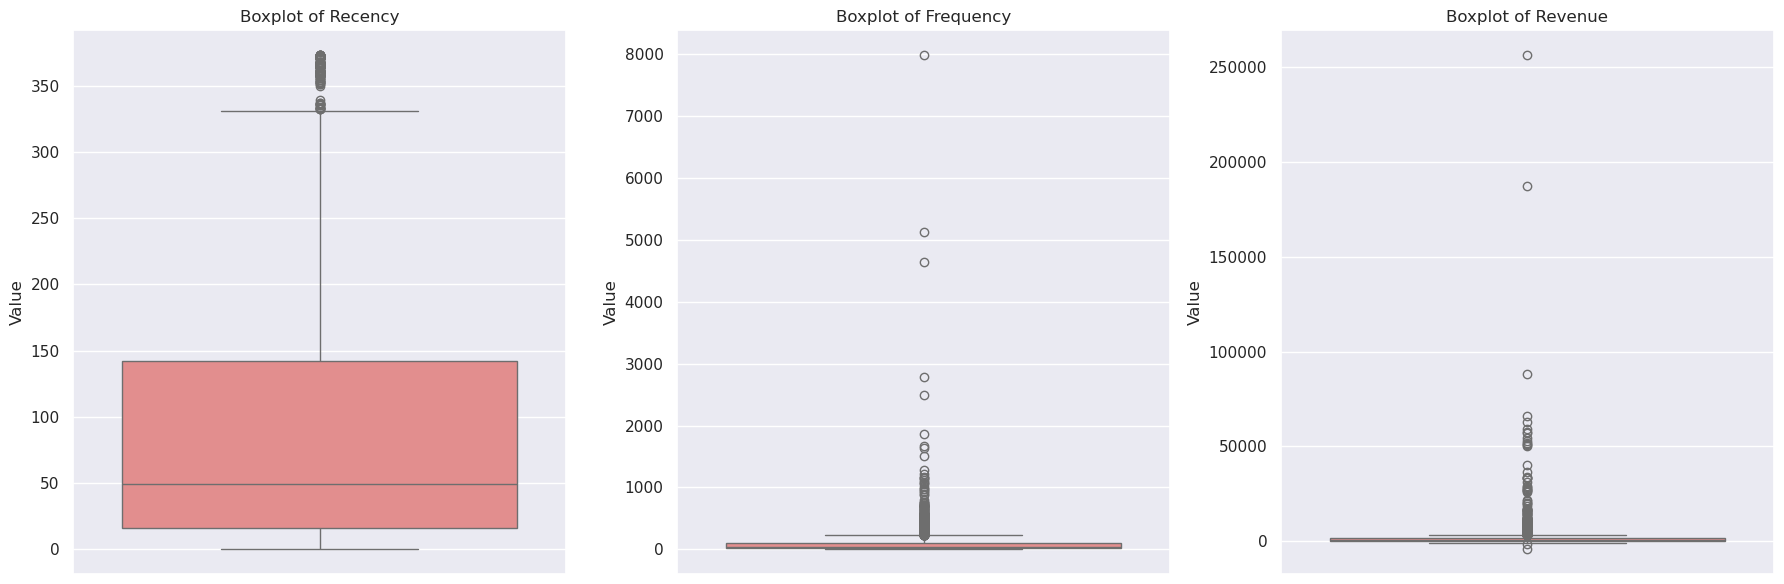

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Recency', 'Frequency', 'Revenue']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

**1.4.** Plot the relative proportions of low, mid and high value customers
using the barplot and table functions. What conclusion should you draw from the
business perspective?

Customer Segment Table:
            Count  Percentage (%)
Segment                          
Low-Value    1958        49.56962
Mid-Value    1848        46.78481
High-Value    144         3.64557


/tmp/ipykernel_32816/2525441507.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
/tmp/ipykernel_32816/2525441507.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, val + (max(segment_counts)*0.01), f'{segment_proportions[i]:.1f}%', ha='center')


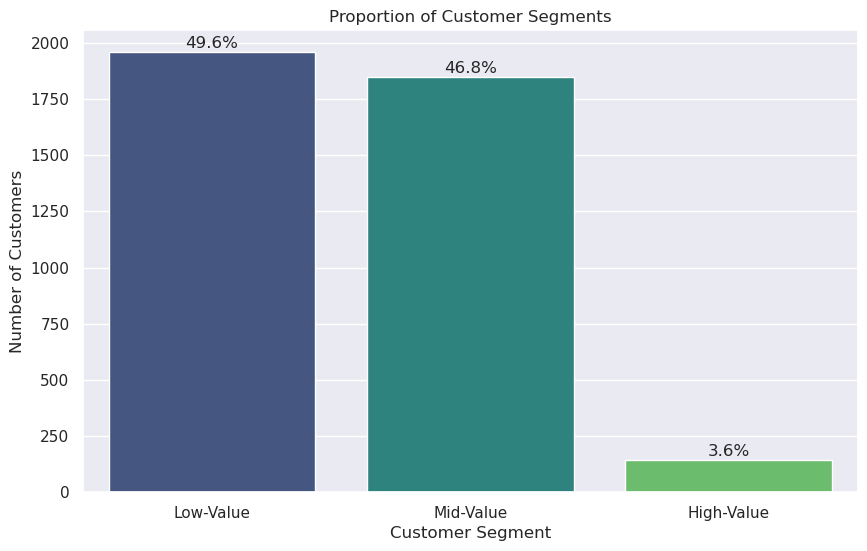

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_counts = df['Segment'].value_counts()
segment_proportions = df['Segment'].value_counts(normalize=True) * 100

segment_table = pd.DataFrame({
    'Count': segment_counts,
    'Percentage (%)': segment_proportions
})

print("Customer Segment Table:")
print(segment_table)

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')

for i, val in enumerate(segment_counts.values):
    plt.text(i, val + (max(segment_counts)*0.01), f'{segment_proportions[i]:.1f}%', ha='center')

plt.title('Proportion of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

### 2. Transform data distributions

When dealing with predictive modelling or some other machine learning
algorithms, it is sometimes preferable to apply the algorithm to normally
distributed data. Likewise, some algorithms will be sensitive to the different
scales of variations between columns and to give the same weight to each
features, you will have to scale each column.

For these reasons, data transformations are a common preprocessing step before
training machine learning models. Here we will experiment with the Box-cox
transformation, min-max scaling and standardization.

Finally, categorical data can be encoded to integer to be taken in as features
for modelling.

**2.1.** Apply the Box-Cox transformation to Recency using ``boxcox`` present in the **scipy**
  package for the Frequency column.


Optimal Lambda for Recency: 0.1722


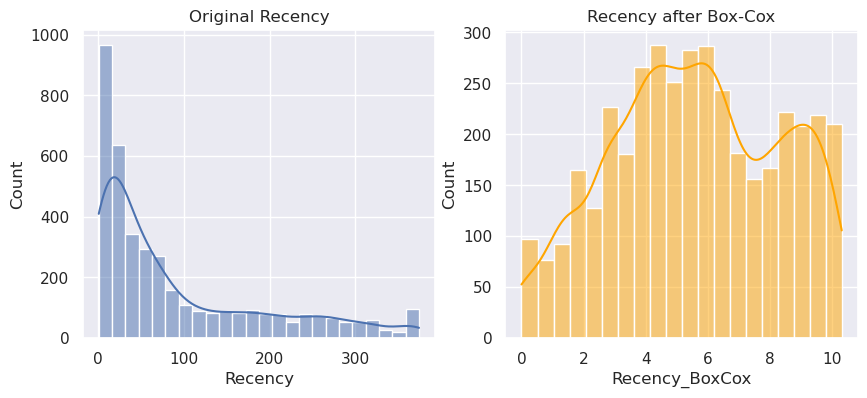

In [ ]:
from scipy import stats
import numpy as np

if (df['Recency'] <= 0).any():
    df['Recency'] = df['Recency'] + 1

df['Recency_BoxCox'], lmbda = stats.boxcox(df['Recency'])

print(f"Optimal Lambda for Recency: {lmbda:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Recency'], kde=True)
plt.title('Original Recency')

plt.subplot(1, 2, 2)
sns.histplot(df['Recency_BoxCox'], kde=True, color='orange')
plt.title('Recency after Box-Cox')
plt.show()

**2.2.** Can you apply the Box-Cox transformation to other columns? If yes, how?

In [27]:
from scipy import stats

cols_to_transform = ['Frequency', 'Revenue']

for col in cols_to_transform:
    if df[col].min() <= 0:
        df[col] = df[col] - df[col].min() + 1
    
    df[col + '_BoxCox'], _ = stats.boxcox(df[col])

print("Columns after transformation:")
print(df[[c + '_BoxCox' for c in cols_to_transform]].head())

Columns after transformation:
   Frequency_BoxCox  Revenue_BoxCox
0          6.859724        9.932441
1          6.307086        9.723914
2          6.212117        9.625876
3          7.058779        9.910062
4          6.232992        9.685539


**2.3.** Transform the segment column to numeric with:

    - Low-Value = 1
    - Mid-Value = 2
    - High-Value = 3

**Hints:**

    - Create a function that converts the segment to segment code
    - Use DataFrame's .apply() method to add a column

<!--- BEGIN SOLUTION --->

In [28]:
def convert_segment_to_code(segment):
    if segment == 'Low-Value':
        return 1
    elif segment == 'Mid-Value':
        return 2
    elif segment == 'High-Value':
        return 3
    else:
        return 0 
df['Segment_Code'] = df['Segment'].apply(convert_segment_to_code)

print(df[['Segment', 'Segment_Code']].drop_duplicates())
print("\nFirst 5 rows:")
print(df[['Segment', 'Segment_Code']].head())

         Segment  Segment_Code
0      Low-Value             1
2      Mid-Value             2
3751  High-Value             3

First 5 rows:
     Segment  Segment_Code
0  Low-Value             1
1  Low-Value             1
2  Mid-Value             2
3  Mid-Value             2
4  Mid-Value             2


<!--- END SOLUTION --->

### 3. Inspect relationships between features

**3.1.** Plot the Revenue, Recency, Frequency distributions using violinplots for each segment.

<!--- BEGIN SOLUTION --->

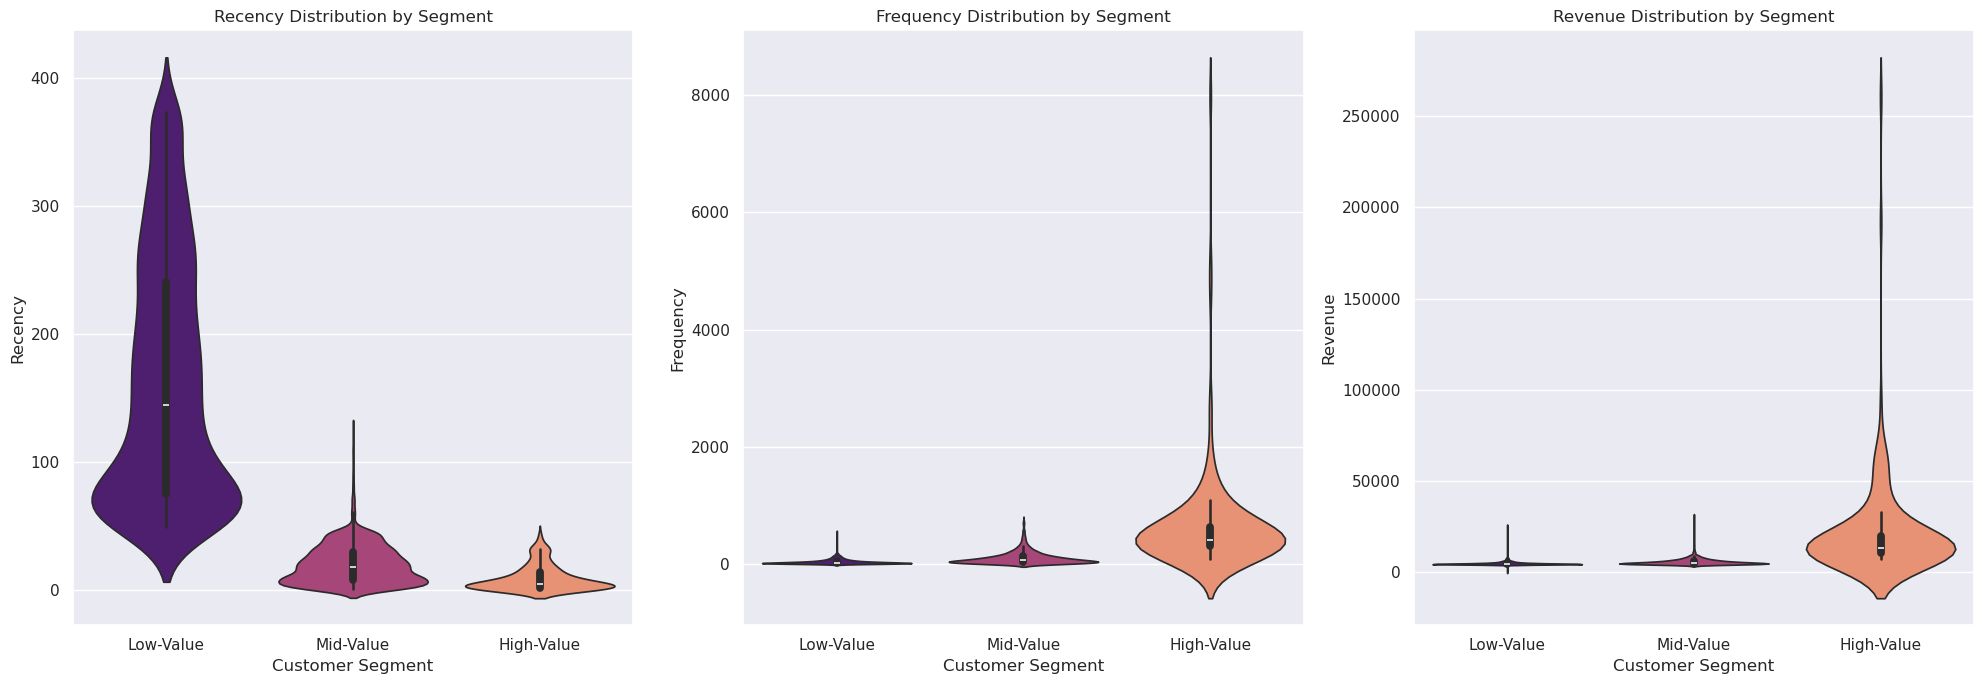

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Recency', 'Frequency', 'Revenue']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, col in enumerate(features):
    sns.violinplot(x='Segment', y=col, data=df, ax=axes[i], palette='magma', hue='Segment', legend=False)
    axes[i].set_title(f'{col} Distribution by Segment')
    axes[i].set_xlabel('Customer Segment')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

<!--- END SOLUTION --->

**3.2.** Compute correlations between Recency, Frequency and Revenue (method corr)
  and plot them using ``heatmap`` from the **seaborn** package. Write about what
  you observe.
  
**Hint:** to visualize the numbers, use `fmt='.2f'` as argument to the heatmap

<!--- BEGIN SOLUTION --->

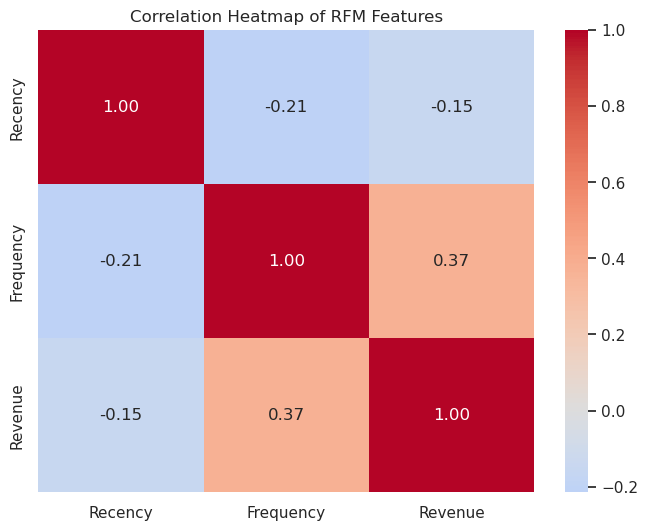

            Recency  Frequency   Revenue
Recency    1.000000  -0.213247 -0.147039
Frequency -0.213247   1.000000  0.366111
Revenue   -0.147039   0.366111  1.000000


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[['Recency', 'Frequency', 'Revenue']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of RFM Features')
plt.show()

print(corr_matrix)

****3.3.** Which correlation coefficient would you need to use to compute the correlations between the Recency, Frequency, Revenue **and the Overall Score**? Plot the new correlation matrix. Write about what
you observe (and do not forget to compare the new correlation matrix with
the former one!)

**Hint:** We have a mix of ordinal data and numeric data, so have a look at the Spearman correlation coefficient.**

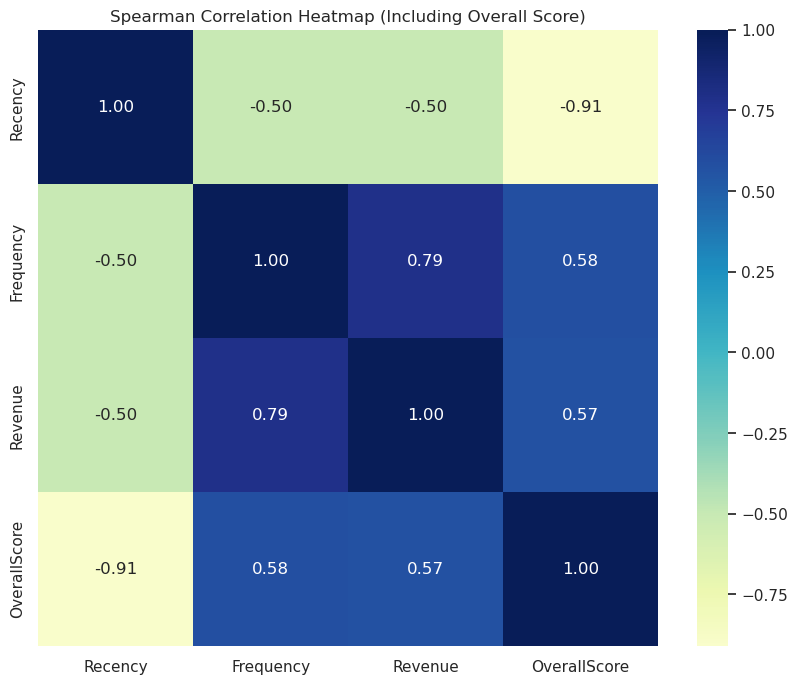

Spearman Correlation Matrix:
               Recency  Frequency   Revenue  OverallScore
Recency       1.000000  -0.504749 -0.503974     -0.909566
Frequency    -0.504749   1.000000  0.788352      0.583419
Revenue      -0.503974   0.788352  1.000000      0.569074
OverallScore -0.909566   0.583419  0.569074      1.000000


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

features_with_score = ['Recency', 'Frequency', 'Revenue', 'OverallScore']

corr_matrix_spearman = df[features_with_score].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.2f', cmap='YlGnBu', center=0)
plt.title('Spearman Correlation Heatmap (Including Overall Score)')
plt.show()

print("Spearman Correlation Matrix:")
print(corr_matrix_spearman)

**3.4.** One important use of correlation is actually to detect features that
are highly correlated and then, in a sense carry the same information. In these
cases, it is generally nessecary to only keep one of those to feed the model
training pipeline. Write a code that will create a dataframe that only keep
a subset of features that have a correlation coefficient of less than .75.

In [32]:
import numpy as np

corr_matrix = df[['Recency', 'Frequency', 'Revenue', 'OverallScore']].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.75)]

print(f"Features to drop (Correlation > 0.75): {to_drop}")

df_subset = df.drop(columns=to_drop)

print("\nRemaining features in the subset:")
print(df_subset.columns.tolist())

Features to drop (Correlation > 0.75): ['OverallScore']

Remaining features in the subset:
['CustomerID', 'Recency', 'RecencyCluster', 'Frequency', 'FrequencyCluster', 'Revenue', 'RevenueCluster', 'Segment', 'Recency_BoxCox', 'Frequency_BoxCox', 'Revenue_BoxCox', 'Segment_Code']


**3.5.** Plot 2d histograms of

- Recency-Frequency
- Recency-Revenue
- Revenue-Frequency

What do you observe?

**Hint:** One option is to use the ``histplot`` from the **seaborn** package, with each feature on a respective axis. Always [check the documentation](https://seaborn.pydata.org/generated/seaborn.histplot.html) to understand how to use a function. You have to provide ``data``, ``x``, and ``y`` at a minimum.

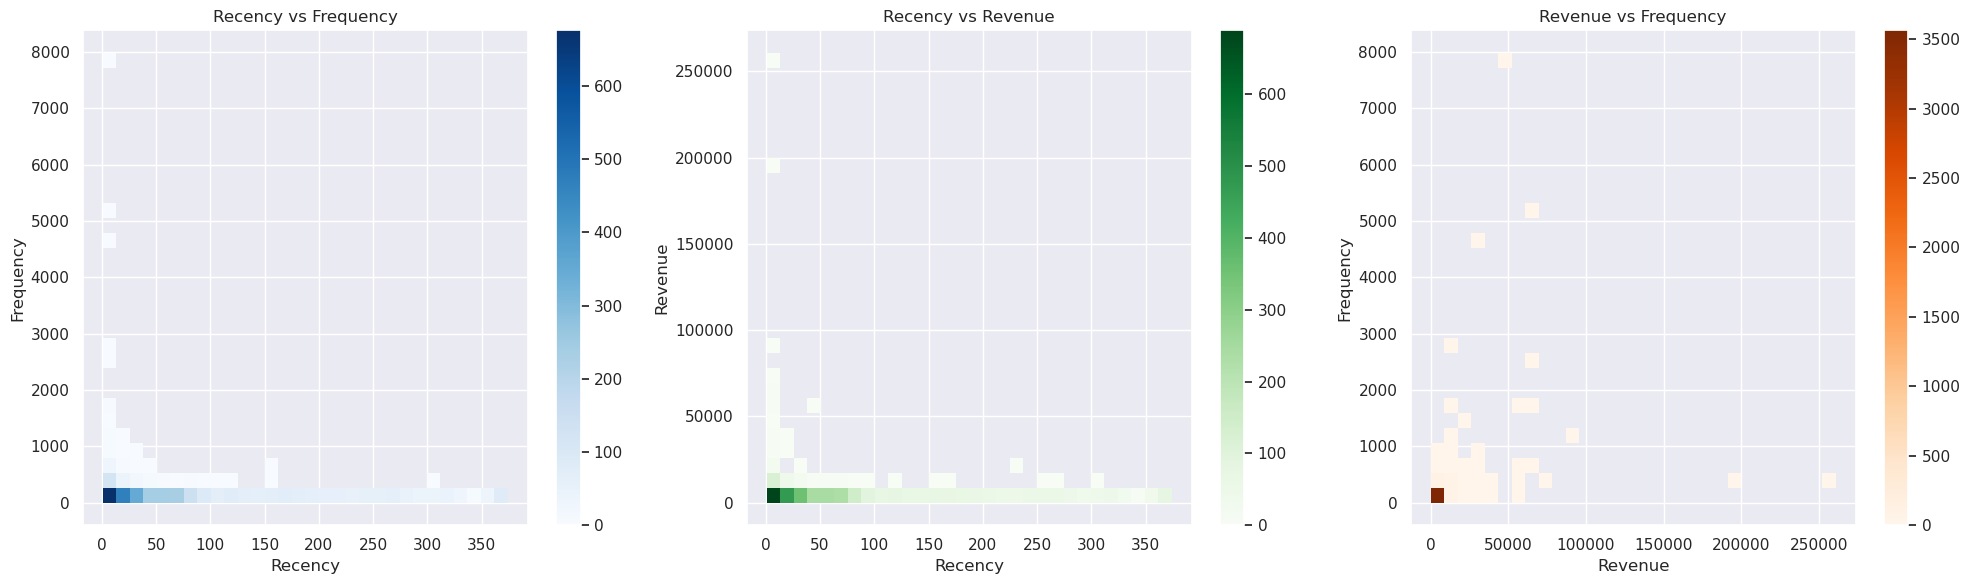

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(data=df, x='Recency', y='Frequency', bins=30, cmap='Blues', cbar=True, ax=axes[0])
axes[0].set_title('Recency vs Frequency')

sns.histplot(data=df, x='Recency', y='Revenue', bins=30, cmap='Greens', cbar=True, ax=axes[1])
axes[1].set_title('Recency vs Revenue')

sns.histplot(data=df, x='Revenue', y='Frequency', bins=30, cmap='Oranges', cbar=True, ax=axes[2])
axes[2].set_title('Revenue vs Frequency')

plt.tight_layout()
plt.show()